# 1. Importações e Configurações

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from google.colab import userdata
from google import genai

Configuração de visualização baseada nas aulas anteriores

In [5]:
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Ingestão e Preparação dos Dados (Pandas)

In [6]:
print("📥 Carregando dados...")
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

📥 Carregando dados...


Limpeza e Transformação

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

Selecionando algumas features para simplificar o exemplo

In [8]:
features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X = df[features]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Visualização Estratégica (Seaborn)

📊 Gerando insights visuais...


/tmp/ipykernel_2818/763455925.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='coolwarm')


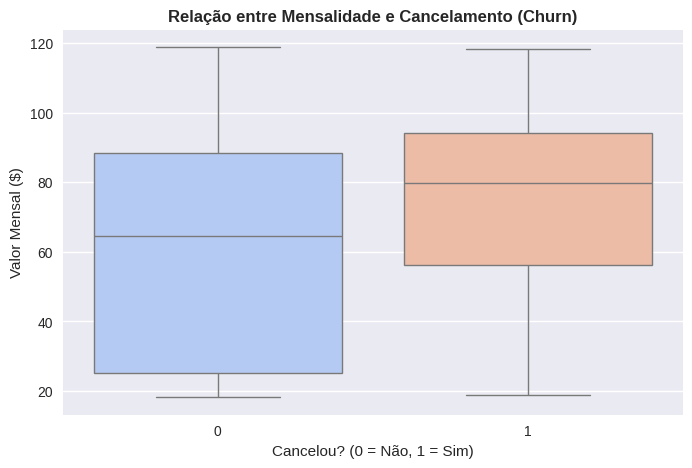

In [9]:
print("📊 Gerando insights visuais...")
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='coolwarm')
plt.title('Relação entre Mensalidade e Cancelamento (Churn)', fontweight='bold')
plt.xlabel('Cancelou? (0 = Não, 1 = Sim)')
plt.ylabel('Valor Mensal ($)')
plt.show()

# 4. Treinamento do Modelo Preditivo (Keras)

In [10]:
print("🧠 Treinando Rede Neural (Keras)...")
model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(3,)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid') # Retorna probabilidade (0 a 1)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, verbose=0)

🧠 Treinando Rede Neural (Keras)...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 5. O Produto: Tomada de Decisão com LLM (Gemini)

Aqui transformamos o modelo em um produto útil para o usuário final!

In [12]:
print("🚀 Gerando plano de ação para clientes em risco...")

🚀 Gerando plano de ação para clientes em risco...


Simulando a predição para um cliente específico do teste

In [16]:
# ==========================================
# 1. BUSCA INTELIGENTE DO CLIENTE EM RISCO
# ==========================================
cliente_idx = 0
probabilidade_churn = 0

print("Buscando um cliente com alto risco na base de testes...")
while probabilidade_churn <= 0.5:
    # Testa o cliente atual
    probabilidade_churn = model.predict(X_test_scaled[cliente_idx].reshape(1, -1), verbose=0)[0][0]

    if probabilidade_churn <= 0.5:
        cliente_idx += 1 # Risco baixo? Pula pro próximo!

print(f"🔎 Encontramos o cliente ideal no índice {cliente_idx}!")
dados_cliente = X_test.iloc[cliente_idx]

# ==========================================
# 2. DECISÃO E AÇÃO
# ==========================================
if probabilidade_churn > 0.5:
    print(f"⚠️ ALERTA: Cliente com {probabilidade_churn:.1%} de risco de churn.")

    # Puxa a chave secreta
    minha_chave = userdata.get("GEMINI_API_KEY")

    prompt = f"""
    Você é um assistente de CRM de uma empresa de telecomunicações.
    O modelo preditivo apontou um alto risco de cancelamento para este cliente:
    - Meses na empresa: {dados_cliente['tenure']}
    - Mensalidade: ${dados_cliente['MonthlyCharges']:.2f}
    - Total gasto: ${dados_cliente['TotalCharges']:.2f}

    Escreva uma mensagem curta (máximo 3 linhas) sugerindo uma ação imediata para o operador de telemarketing oferecer a este cliente e evitar o cancelamento. Seja direto e focado em retenção.
    """

    # Chama o Gemini
    client = genai.Client(api_key=minha_chave)

    resposta = client.models.generate_content(
        model='gemini-3.6-flash',
        contents=prompt
    )

    print("\n📝 SUGESTÃO DE AÇÃO PARA O CRM:")
    print(resposta.text)

else:
    print("✅ Cliente estável. Nenhuma ação de retenção imediata necessária.")

Buscando um cliente com alto risco na base de testes...
🔎 Encontramos o cliente ideal no índice 2!
⚠️ ALERTA: Cliente com 70.2% de risco de churn.

📝 SUGESTÃO DE AÇÃO PARA O CRM:
**Diagnóstico:** Cliente de alto valor ($102,25/mês) no 13º mês, com alto risco por provável fim da promoção de adesão.
**Ação Imediata:** Ofereça o **"Bônus de Aniversário de 1 Ano"**: desconto de 20% a 25% na mensalidade mediante nova fidelização por 12 meses.
**Foco:** Reduzir o custo percebido e reter proativamente um cliente que já gerou $1.359,00 antes que ele solicite o cancelamento.
